In [63]:
import  numpy as  np  
import pandas  as pd  
df = pd.read_csv('newplacementdata - newplacementdata.csv')
df

,cgpa,placement_exam_marks,placed
0,7.19,26,1
1,7.46,38,1
2,7.54,40,1
3,6.42,8,1
4,7.23,17,0
...,...,...,...
995,8.87,44,1
996,9.12,65,1
997,4.89,34,0
998,8.62,46,1


In [64]:
df.head()

,cgpa,placement_exam_marks,placed
0,7.19,26,1
1,7.46,38,1
2,7.54,40,1
3,6.42,8,1
4,7.23,17,0


In [65]:
# odd  =  (n/2)+1 
# EVEN  = ((n/2) +  ((n/2)+1))/2
!pip install seaborn



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [66]:
import matplotlib.pyplot as  plt  
import  seaborn  as  sns  
df['placement_exam_marks'].describe()

count    1000.000000
mean       32.225000
std        19.130822
min         0.000000
25%        17.000000
50%        28.000000
75%        44.000000
max       100.000000
Name: placement_exam_marks, dtype: float64

<Axes: xlabel='placement_exam_marks'>

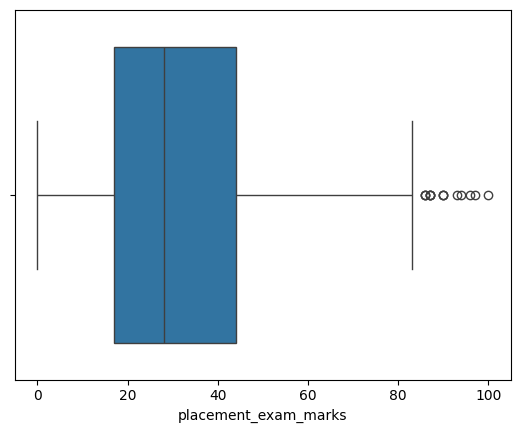

In [67]:
sns.boxplot(x=df['placement_exam_marks'])

In [68]:
#  finding  the  IQR :-
percentile25 = df['placement_exam_marks'].quantile(0.25)
percentile75 = df['placement_exam_marks'].quantile(0.75)
percentile25

np.float64(17.0)

percentile75

In [69]:
# IQR
IQR = percentile75 -percentile25
IQR

np.float64(27.0)

In [70]:
upper_limit = percentile75+1.5*IQR
lower_limit = percentile25 -1.5*IQR
upper_limit

np.float64(84.5)

In [71]:
lower_limit

np.float64(-23.5)

In [1]:
#  find  out  outlier  

In [72]:
df[df['placement_exam_marks']>upper_limit]

,cgpa,placement_exam_marks,placed
9,7.75,94,1
40,6.60,86,1
61,7.51,86,0
134,6.33,93,0
162,7.80,90,0
283,7.09,87,0
290,8.38,87,0
311,6.97,87,1
324,6.64,90,0
630,6.56,96,1


In [73]:
df[df['placement_exam_marks']<lower_limit]

,cgpa,placement_exam_marks,placed


In [13]:
# trimming ---->(4 lower).......1,upper(25)........(50)-------->>>> here 1,50 are  outliers-------->
# lower(4)<<<<<--------->>>>>>upper(25) mid  data.

# capping------>>>>>>(4 lower).......1,upper(25)........(50)-------->>>>capping lower point lowest point (1)
# upper point upper point(50)------->>>>> range expand ----->>>>>. outlier remove  . 

In [74]:
# trimming(outlier removeig  technique 1)
new_df =  df[df['placement_exam_marks']<upper_limit]

In [15]:
# new_df

In [16]:
# comparision

In [75]:
plt.figure(figsize=(15,5))

<Figure size 1500x500 with 0 Axes>

<Figure size 1500x500 with 0 Axes>

<Axes: xlabel='placement_exam_marks'>

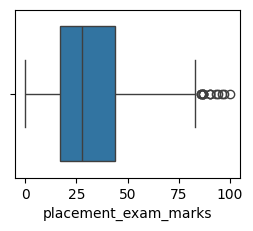

In [37]:
plt.subplot(222)
sns.boxplot(x= df['placement_exam_marks'])

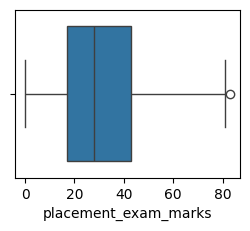

In [38]:
plt.subplot(224)
sns.boxplot(x=new_df['placement_exam_marks'])
plt.show()

In [39]:
# capping(outlier  removing  technique  2)
new_df_cap = df.copy()

In [40]:
# min =5,max=15
# min 4,3,1
# updated_min_value  = 1  
# updated_max_value  = 50 

In [41]:
new_df_cap['placement_exam_marks'] = np.where(
                                     new_df_cap['placement_exam_marks']>upper_limit,
                                     upper_limit,

                                     np.where(new_df_cap['placement_exam_marks']<lower_limit,
                                     lower_limit, 
                                     new_df_cap['placement_exam_marks']))

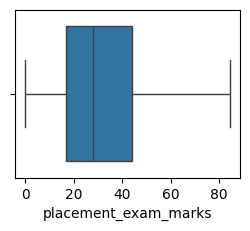

In [44]:
plt.subplot(224)
sns.boxplot(x=new_df_cap['placement_exam_marks'])
plt.show()

In [45]:
#   work or task   :
# titanic  dataset ------->>>>age------>>>>>>outlier--------->>>>>>>check
# handel  --------->>>>>>trimming,capping 


In [76]:
import  numpy as  np 
import  pandas  as  pd  

df =  pd.read_csv('titanic - titanic.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [93]:
import matplotlib.pyplot as  plt
import  seaborn as  sns 
df['Age'].describe()

count    332.000000
mean      30.272590
std       14.181209
min        0.170000
25%       21.000000
50%       27.000000
75%       39.000000
max       76.000000
Name: Age, dtype: float64

<Axes: xlabel='Age'>

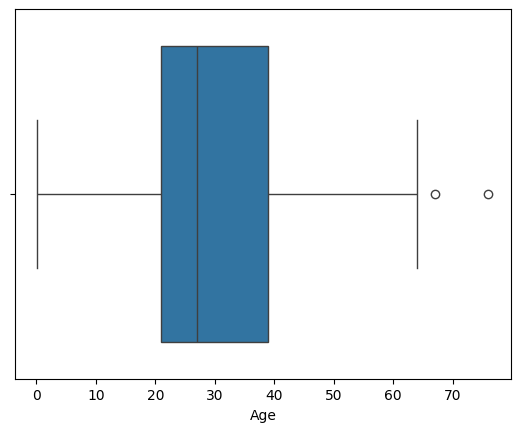

In [94]:
sns.boxplot(x=df['Age'])

In [95]:
# IQR find 
percentile_25 = df['Age'].quantile(0.25)
percentile_75 = df['Age'].quantile(0.75)

In [96]:
IQR = percentile_75 - percentile_25

In [97]:
upper_limit =  percentile_75 + 1.5*IQR
lower_limit =  percentile_25 - 1.5*IQR

In [98]:
df[df['Age']>upper_limit]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
81,973,0,1,"Straus, Mr. Isidor",male,67.0,1,0,PC 17483,221.7792,C55 C57,S
96,988,1,1,"Cavendish, Mrs. Tyrell William (Julia Florence...",female,76.0,1,0,19877,78.8500,C46,S


In [99]:
df[df['Age']<lower_limit]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked


In [103]:
# trimming  
new_df = df[df['Age']<upper_limit]


<Axes: xlabel='Age'>

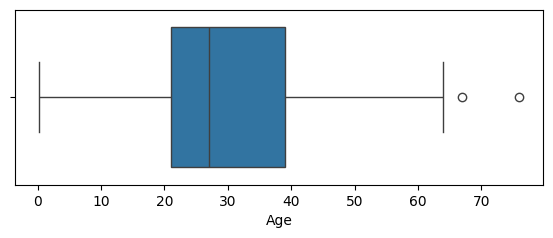

In [104]:
plt.figure(figsize = (15,5))

plt.subplot(222)

sns.boxplot(x = df['Age'])

<Axes: xlabel='Age'>

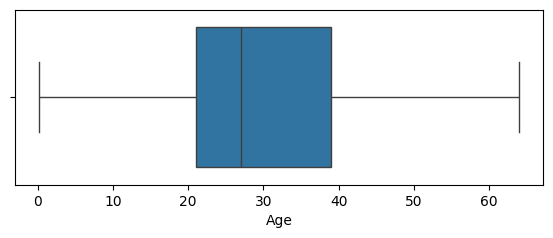

In [105]:
plt.figure(figsize = (15,5))
plt.subplot(224)
sns.boxplot(x=new_df['Age'])

In [107]:
#  now  use  second  method (capping):-
new_df_cap = df.copy()

In [109]:
new_df_cap['Age'] = np.where(new_df_cap['Age']>upper_limit,upper_limit,
            np.where(new_df_cap['Age']<lower_limit,lower_limit,new_df_cap['Age'])
                    )

<Axes: xlabel='Age'>

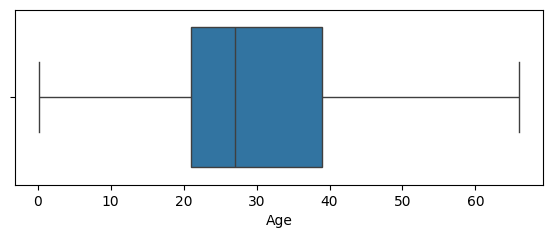

In [110]:
plt.figure(figsize = (15,5))
plt.subplot(224)
sns.boxplot(x= new_df_cap['Age'])